Original dataset shape: (10884, 33)
Updated dataset shape: (1798, 33)
Number of lines present in both datasets: 1798
IDs match in order: True
x: 1605 lines changed (89.27%)
r: 1605 lines changed (89.27%)
b: 1605 lines changed (89.27%)
s_nom: 0 lines changed (0.00%)
x_pu: 0 lines changed (0.00%)
r_pu: 0 lines changed (0.00%)
b_pu: 0 lines changed (0.00%)
s_nom_opt: 0 lines changed (0.00%)


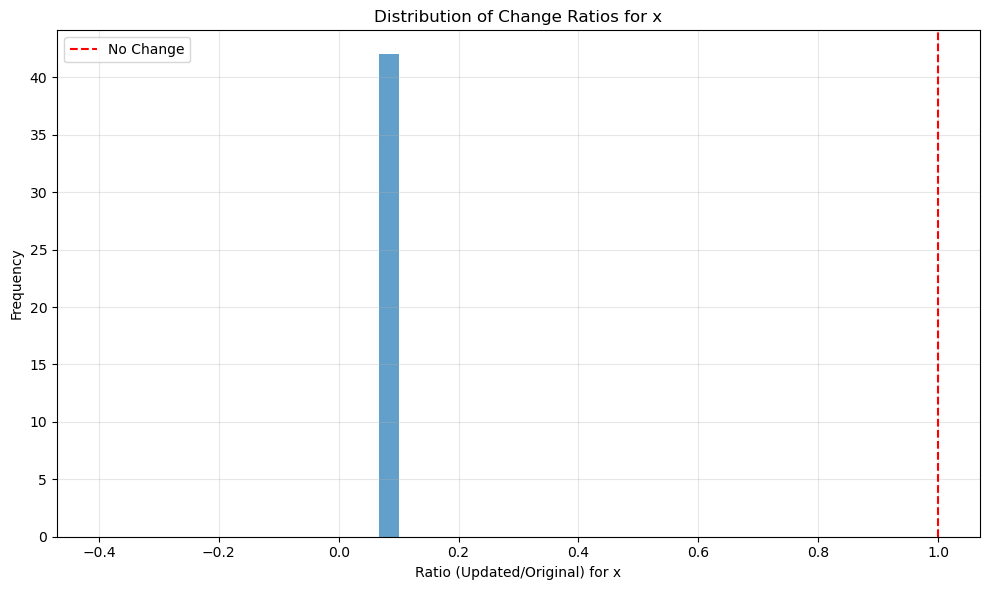

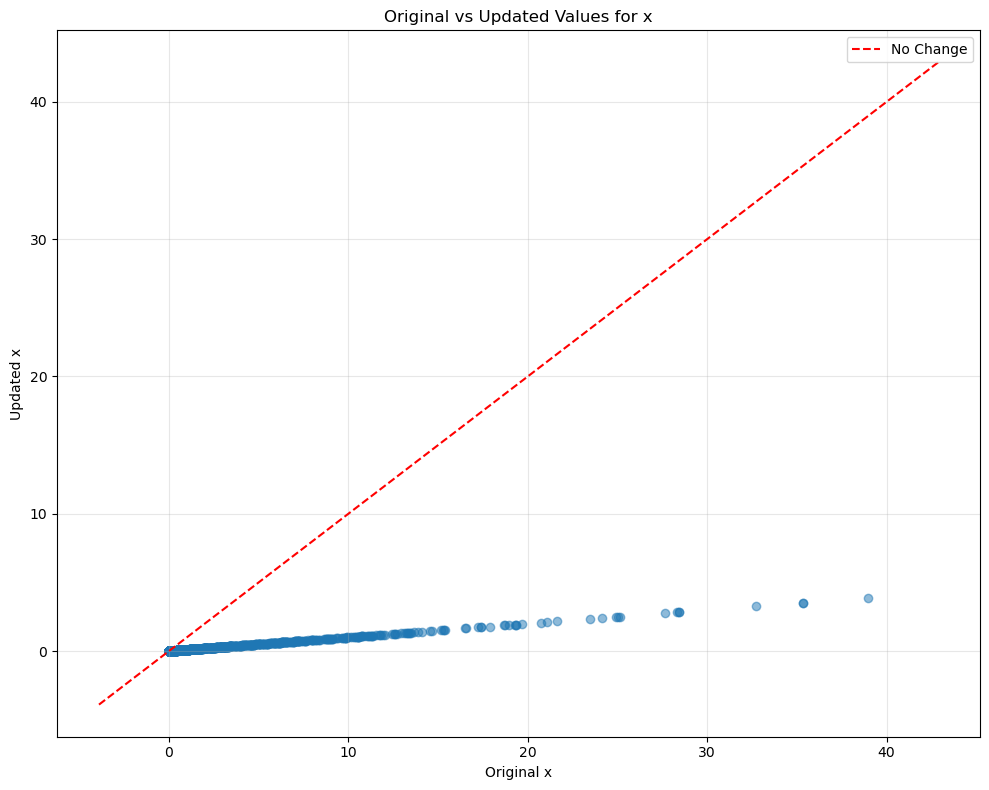

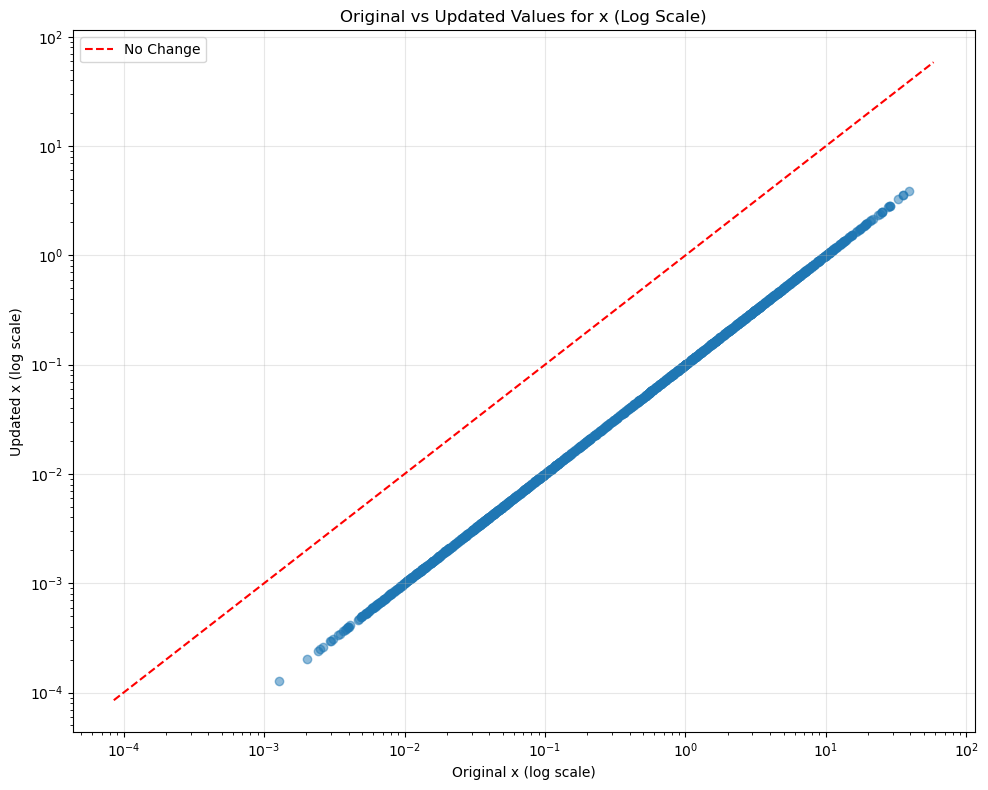

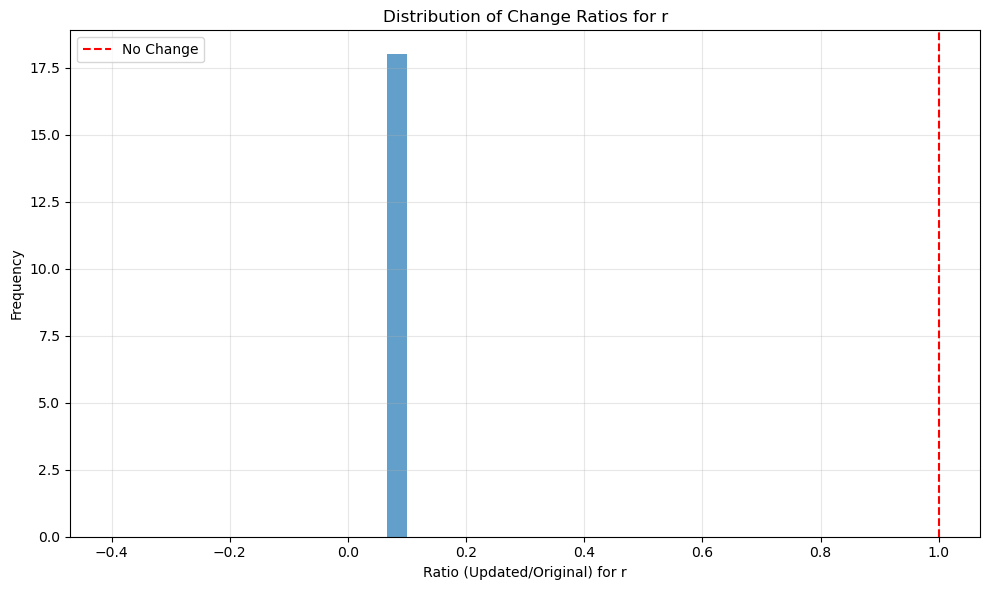

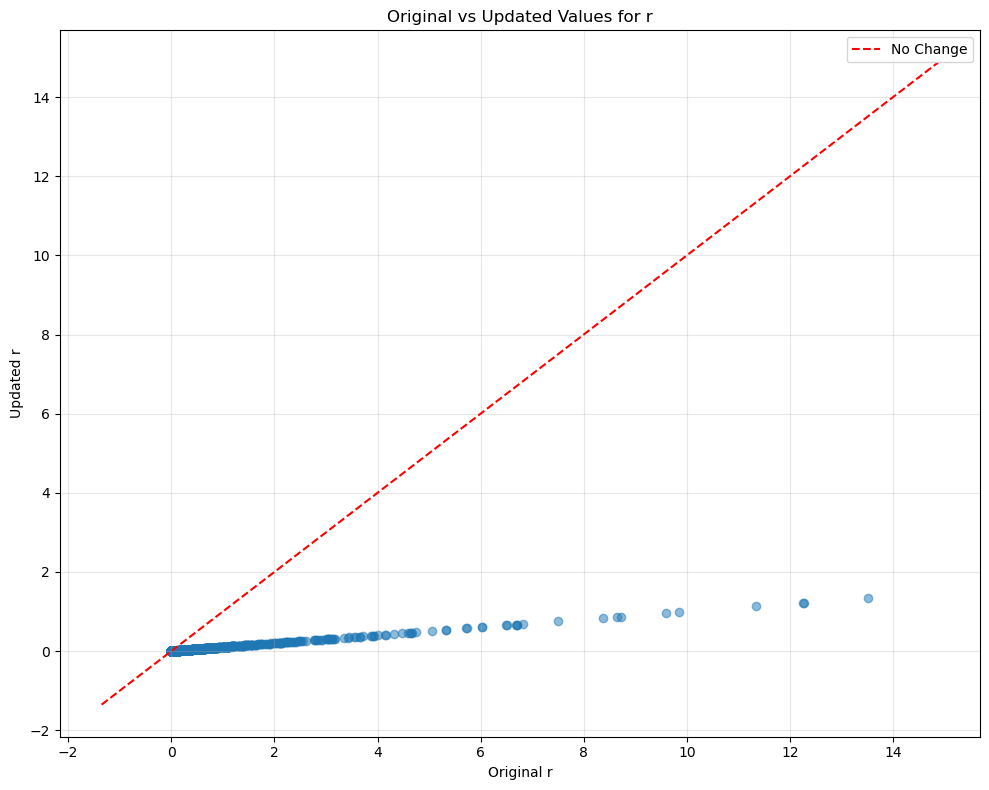

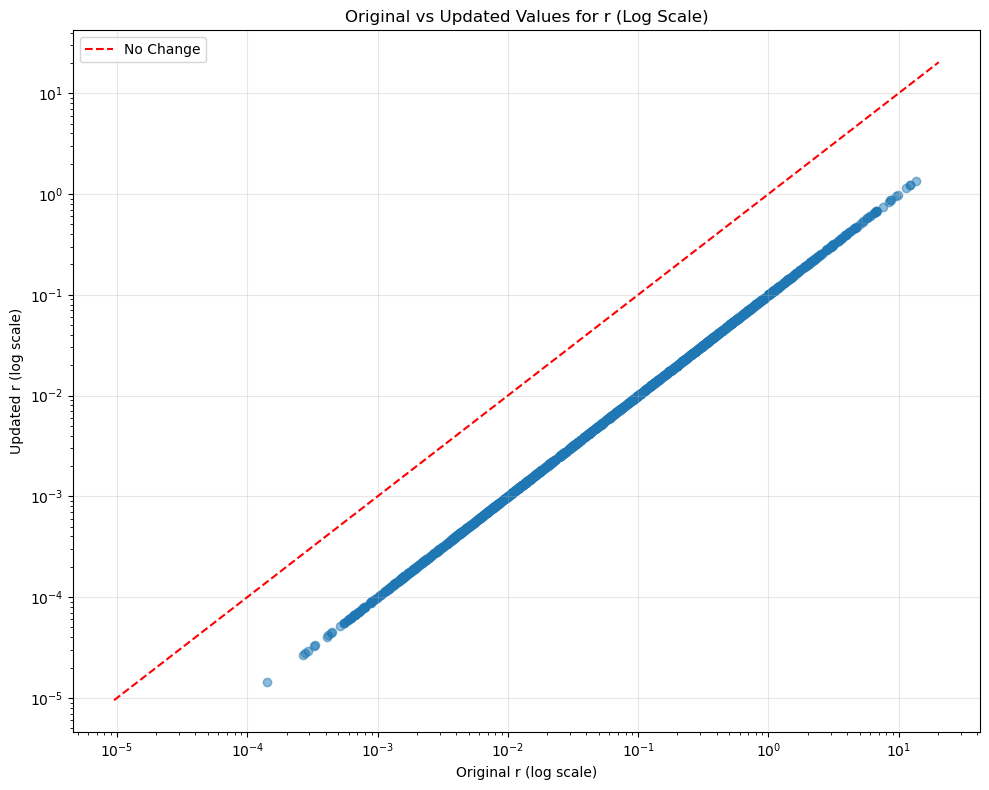

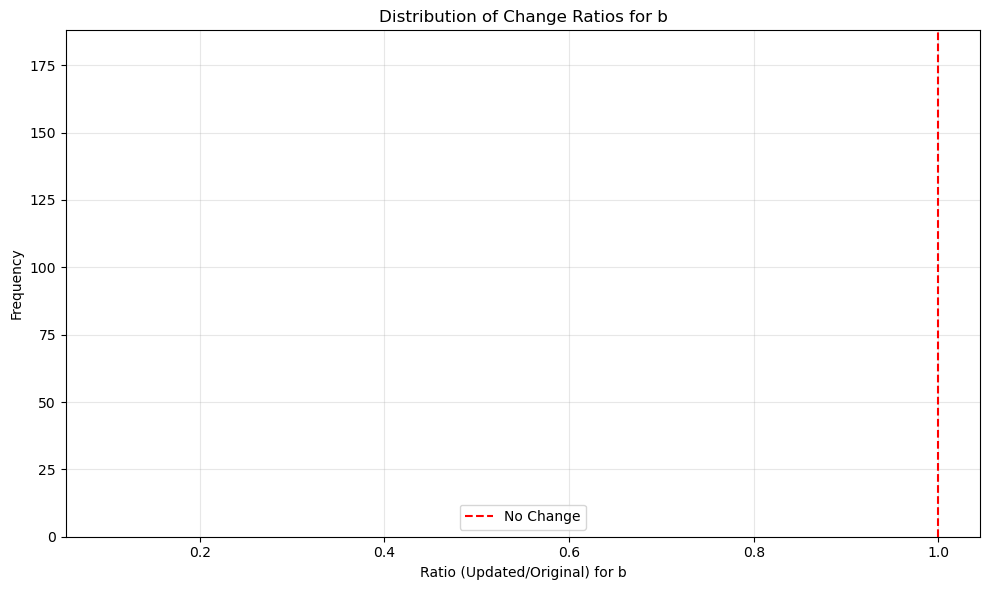

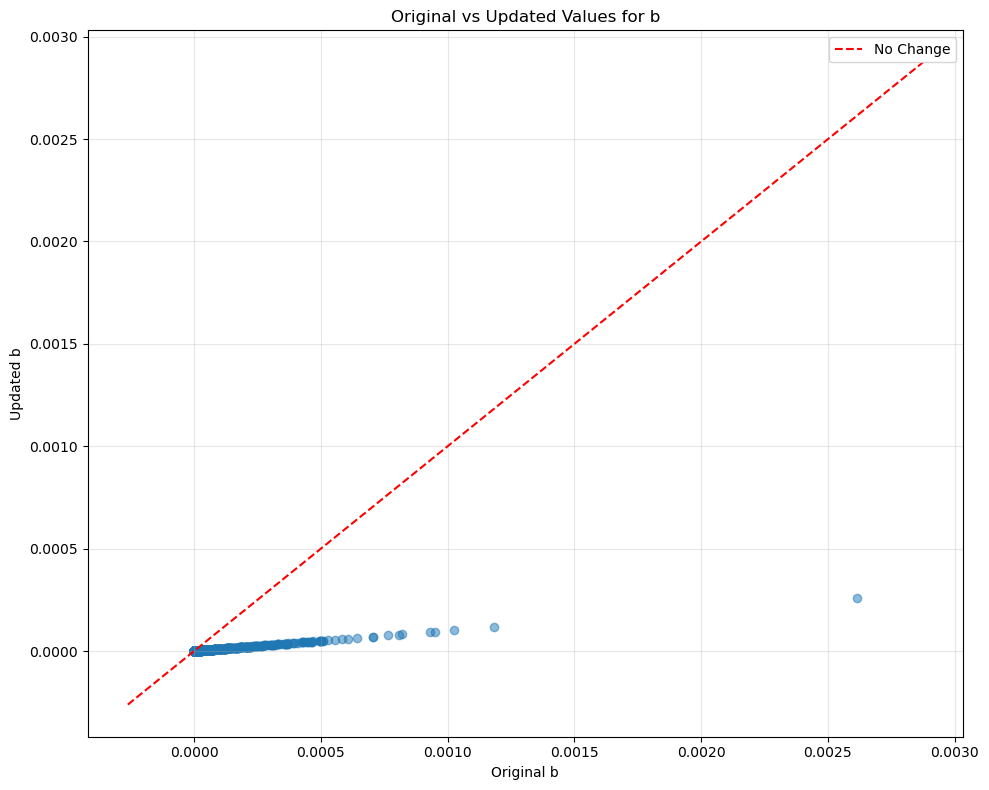

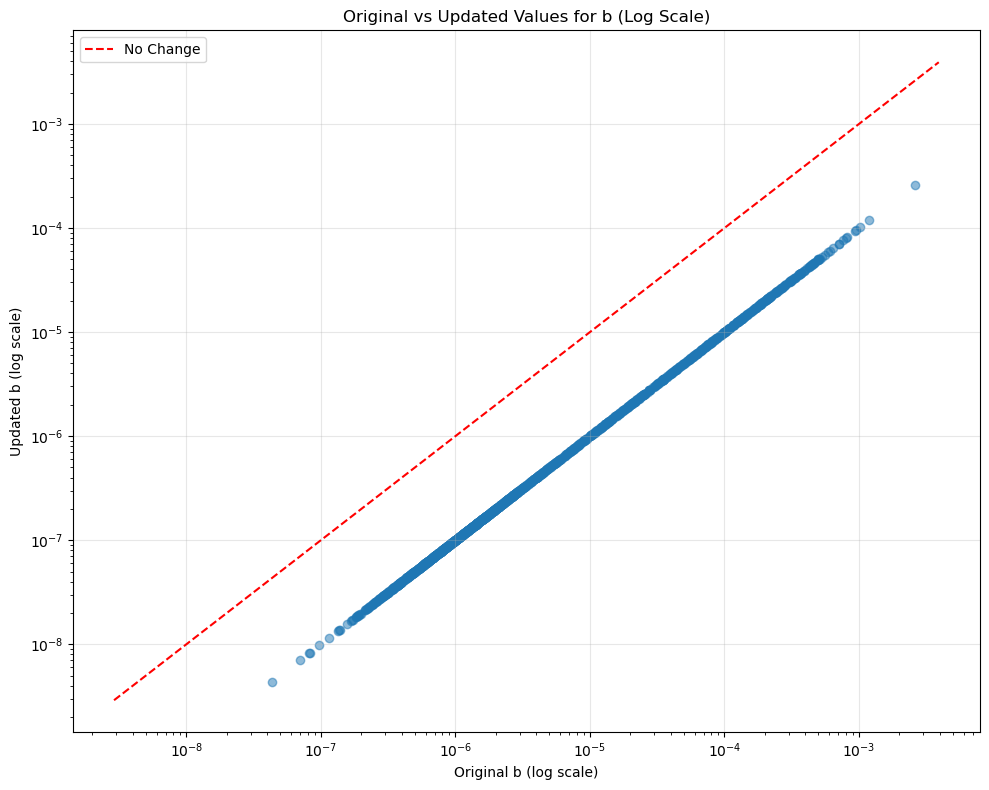

Analysis complete. Results saved to lightsource/analysis_changed_lines


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Paths to your CSV files
lines_original_path = "lightsource/lines_original.csv"
lines_updated_path = "lightsource/lines_updated.csv"

# Create output directory
output_dir = "lightsource/analysis_changed_lines"
os.makedirs(output_dir, exist_ok=True)

# Read the CSVs
original_df = pd.read_csv(lines_original_path)
updated_df = pd.read_csv(lines_updated_path)

# Fix column name differences
updated_df = updated_df.rename(columns={'Bus0': 'bus0', 'Bus1': 'bus1'})

print("Original dataset shape:", original_df.shape)
print("Updated dataset shape:", updated_df.shape)

# Extract lines that exist in both datasets
common_ids = set(original_df['id']).intersection(set(updated_df['id']))
print(f"Number of lines present in both datasets: {len(common_ids)}")

# Filter both dataframes to only include common lines
orig_common = original_df[original_df['id'].isin(common_ids)].copy()
updt_common = updated_df[updated_df['id'].isin(common_ids)].copy()

# Sort both by ID to ensure they're aligned
orig_common.sort_values('id', inplace=True)
updt_common.sort_values('id', inplace=True)

# Reset indices
orig_common.reset_index(drop=True, inplace=True)
updt_common.reset_index(drop=True, inplace=True)

# Verify they have the same IDs in the same order
id_match = (orig_common['id'] == updt_common['id']).all()
print(f"IDs match in order: {id_match}")

# Columns to analyze for changes
numeric_cols = ['x', 'r', 'b', 's_nom', 'x_pu', 'r_pu', 'b_pu', 's_nom_opt']
columns_to_analyze = numeric_cols

# Find out which columns have changed between the two datasets
changed_count = {}
total_matches = len(orig_common)

for col in columns_to_analyze:
    # Convert to the same data type to avoid false differences
    orig_common[col] = pd.to_numeric(orig_common[col], errors='coerce')
    updt_common[col] = pd.to_numeric(updt_common[col], errors='coerce')
    
    # Count how many values have changed
    changed = ~np.isclose(orig_common[col], updt_common[col], rtol=1e-5, equal_nan=True)
    changed_count[col] = changed.sum()
    
    # Calculate percentage
    pct_changed = 100 * changed.sum() / total_matches
    print(f"{col}: {changed.sum()} lines changed ({pct_changed:.2f}%)")

# Save summary to file
with open(os.path.join(output_dir, "changes_summary.txt"), "w") as f:
    f.write(f"Original dataset shape: {original_df.shape}\n")
    f.write(f"Updated dataset shape: {updated_df.shape}\n")
    f.write(f"Number of lines present in both datasets: {len(common_ids)}\n\n")
    f.write("Changes by column:\n")
    for col in columns_to_analyze:
        pct_changed = 100 * changed_count[col] / total_matches
        f.write(f"{col}: {changed_count[col]} lines changed ({pct_changed:.2f}%)\n")

# Create visualizations for each column that changed
for col in columns_to_analyze:
    if changed_count[col] > 0:
        # Create DataFrame with before and after values for lines that changed
        changed_idx = ~np.isclose(orig_common[col], updt_common[col], rtol=1e-5, equal_nan=True)
        if changed_idx.sum() > 0:
            changes_df = pd.DataFrame({
                'id': orig_common.loc[changed_idx, 'id'],
                'original': orig_common.loc[changed_idx, col],
                'updated': updt_common.loc[changed_idx, col]
            })
            
            # Save the data for this column
            changes_df.to_csv(os.path.join(output_dir, f"{col}_changes.csv"), index=False)
            
            # Calculate ratios for plotting
            changes_df['ratio'] = changes_df['updated'] / changes_df['original']
            
            # Filter out any inf or very large ratios for visualization
            valid_ratios = changes_df['ratio'].replace([np.inf, -np.inf], np.nan).dropna()
            filter_mask = (valid_ratios > 0.1) & (valid_ratios < 10)  # Adjust range as needed
            filtered_ratios = valid_ratios[filter_mask]
            
            if len(filtered_ratios) > 0:
                # 1. Histogram of ratios (update/original)
                plt.figure(figsize=(10, 6))
                plt.hist(filtered_ratios, bins=30, alpha=0.7)
                plt.axvline(x=1, color='r', linestyle='--', label='No Change')
                plt.xlabel(f'Ratio (Updated/Original) for {col}')
                plt.ylabel('Frequency')
                plt.title(f'Distribution of Change Ratios for {col}')
                plt.grid(True, alpha=0.3)
                plt.legend()
                plt.tight_layout()
                plt.show()
                plt.savefig(os.path.join(output_dir, f"{col}_ratio_histogram.png"))
                plt.close()
            
            # 2. Scatter plot of original vs updated
            plt.figure(figsize=(10, 8))
            plt.scatter(changes_df['original'], changes_df['updated'], alpha=0.5)
            
            # Add diagonal line representing no change
            max_val = max(changes_df['original'].max(), changes_df['updated'].max())
            min_val = min(changes_df['original'].min(), changes_df['updated'].min())
            # Add some margin to the plot
            margin = (max_val - min_val) * 0.1
            plt.plot([min_val-margin, max_val+margin], [min_val-margin, max_val+margin], 
                     'r--', label='No Change')
            
            plt.xlabel(f'Original {col}')
            plt.ylabel(f'Updated {col}')
            plt.title(f'Original vs Updated Values for {col}')
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()
            plt.savefig(os.path.join(output_dir, f"{col}_scatter.png"))
            plt.close()
            
            # 3. Check if log scale would be better for visualization
            if (changes_df['original'].min() > 0 and changes_df['updated'].min() > 0 and
                max_val / min_val > 10):
                
                plt.figure(figsize=(10, 8))
                plt.scatter(changes_df['original'], changes_df['updated'], alpha=0.5)
                plt.xscale('log')
                plt.yscale('log')
                
                # Add diagonal line representing no change
                plt.plot([min_val/1.5, max_val*1.5], [min_val/1.5, max_val*1.5], 
                         'r--', label='No Change')
                
                plt.xlabel(f'Original {col} (log scale)')
                plt.ylabel(f'Updated {col} (log scale)')
                plt.title(f'Original vs Updated Values for {col} (Log Scale)')
                plt.grid(True, alpha=0.3)
                plt.legend()
                plt.tight_layout()
                plt.show()
                plt.savefig(os.path.join(output_dir, f"{col}_scatter_log.png"))
                plt.close()

print(f"Analysis complete. Results saved to {output_dir}")